                                              **Student Performance** **Indicator**

Life Cycle Of Machine Learning

-->understand the  problem statement

-->Importing the dependices

-->collect the data

-->exploratory data analysis

-->data pre-processing

-->Model Training

-->choosing the best model

Importing the dependices

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LinearRegression

Import the csv data

In [3]:
study_dataset = pd.read_csv(r'C:\Users\tunga\OneDrive\Documents\ML Projects\Note book\data\stud.csv')

showing top 5 records

In [4]:
study_dataset.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
study_dataset.tail()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [6]:
study_dataset.shape

(1000, 8)

In [7]:
study_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


In [8]:
study_dataset.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
study_dataset.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [10]:
study_dataset.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

Exploring the data

In [11]:
print("categories in 'gender' variable : ", end="")
print(study_dataset['gender'].unique())

categories in 'gender' variable : <ArrowStringArray>
['female', 'male']
Length: 2, dtype: str


In [12]:
print("categories in 'race_ethnicity' variable: ",end="")
print(study_dataset['race_ethnicity'].unique())

print("categories in 'parental_level_of_education' variable: ",end="")
print(study_dataset['parental_level_of_education'].unique())

print("categories in 'lunch' variable: ",end="")
print(study_dataset['lunch'].unique())

print("categories in 'test_preparation_course' variable: ",end="")
print(study_dataset['test_preparation_course'].unique())

categories in 'race_ethnicity' variable: <ArrowStringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
categories in 'parental_level_of_education' variable: <ArrowStringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
categories in 'lunch' variable: <ArrowStringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
categories in 'test_preparation_course' variable: <ArrowStringArray>
['none', 'completed']
Length: 2, dtype: str


In [13]:
#define categrical columns and numerical columns
numeric_features = [feature for  feature in study_dataset.columns if study_dataset[feature].dtype != 'str' ]
categorical_features = [feature for feature in study_dataset.columns if study_dataset[feature].dtype == 'str' ]

print('we have {} numerical features : {}'.format(len(numeric_features) ,  numeric_features))
print('\nwe have {} categorical features: {}'.format(len(categorical_features) , categorical_features))



we have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

we have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


Adding columns for total score and average score

In [14]:
study_dataset['total score'] = study_dataset['math_score'] + study_dataset['reading_score'] + study_dataset['writing_score']
study_dataset['average'] = study_dataset['total score']/3
study_dataset.head()


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


students with full marks

In [15]:
reading_full = study_dataset[study_dataset['reading_score'] == 100].shape[0]

writing_full = study_dataset[study_dataset['writing_score'] == 100].shape[0]

math_full = study_dataset[study_dataset['math_score'] == 100].shape[0]

print("Reading full score:", reading_full)
print("Writing full score:", writing_full)
print("Math full score:", math_full)

Reading full score: 17
Writing full score: 14
Math full score: 7


In [16]:
reading_less_20 = study_dataset[study_dataset['reading_score'] <=20].shape[0]
writing_less_20 = study_dataset[study_dataset['writing_score'] <=20].shape[0]
math_score_20 = study_dataset[study_dataset['math_score'] <=20].shape[0]

print("Reading score less than 20:",reading_less_20)
print("Writing score less than 20:",writing_less_20)
print("math score less than 20:",math_score_20)

Reading score less than 20: 1
Writing score less than 20: 3
math score less than 20: 4


Exploratory data analysis

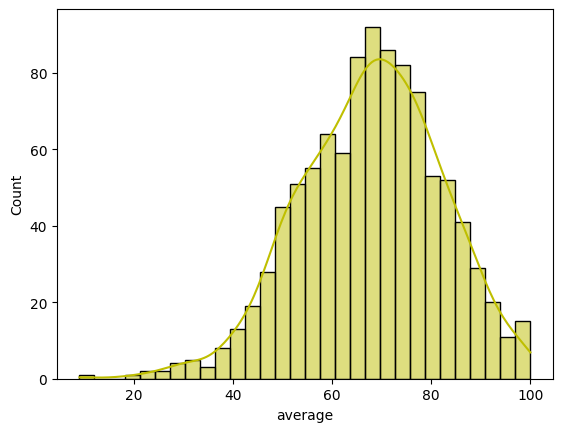

In [17]:
#histogram
plt.Figure(figsize=(6,6))
sns.histplot(data=study_dataset , x='average' , bins=30 ,kde=True , color='y')
plt.show()

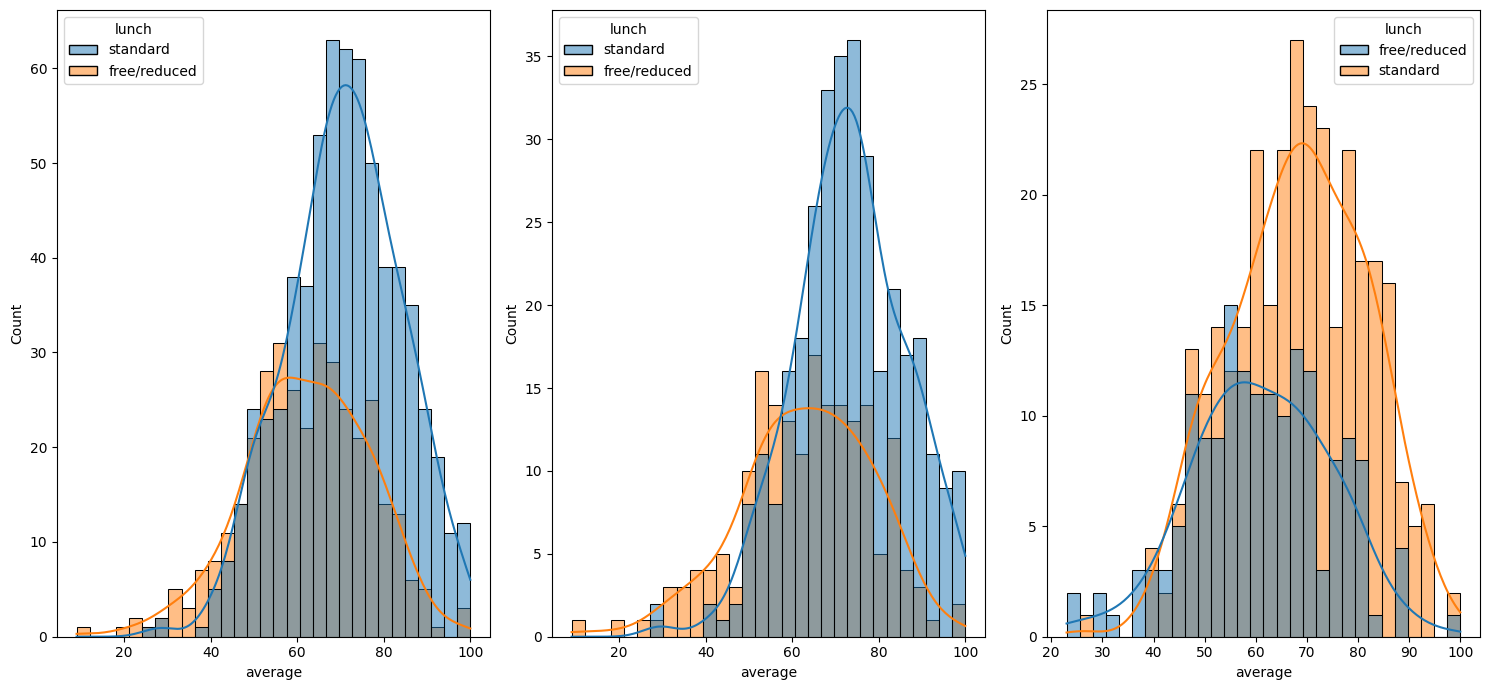

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

sns.histplot(data=study_dataset, x='average', bins=30, kde=True, hue='lunch', ax=axes[0])

sns.histplot(data=study_dataset[study_dataset.gender == 'female'], x='average', bins=30, kde=True, hue='lunch', ax=axes[1])

sns.histplot(data=study_dataset[study_dataset.gender == 'male'], x='average', bins=30, kde=True, hue='lunch', ax=axes[2])

plt.tight_layout()
plt.show()

preparing X and Y variables

In [19]:
X = study_dataset.drop(columns=['math_score'])
Y = study_dataset['math_score']

In [20]:
print(X)

     gender race_ethnicity parental_level_of_education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test_preparation_course  reading_score  writing_score  total score  \
0                      none             72             74    

In [21]:
print(Y)

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64


In [22]:
#create a  column transforming with 3 types of transformers

numeric_features = X.select_dtypes(exclude = "object").columns
categorical_features = X.select_dtypes(include = "object").columns

from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder" , oh_transformer , categorical_features),
        ("StandardScaler" , numeric_transformer , numeric_features)
    ]
)





In [23]:
X = preprocessor.fit_transform(X)

Train test split

In [24]:
X_train , X_test , Y_train , Y_test = train_test_split(X ,Y , test_size=0.2 , random_state=42)

In [25]:
print(X_train)

[[ 1.          0.          0.         ...  0.45733301  0.08626782
   0.08626782]
 [ 1.          0.          0.         ...  0.98406266  0.67105512
   0.67105512]
 [ 1.          0.          0.         ...  1.18158627  1.18566794
   1.18566794]
 ...
 [ 1.          0.          0.         ... -0.99117351 -0.82600036
  -0.82600036]
 [ 0.          1.          0.         ... -0.99117351 -1.22365572
  -1.22365572]
 [ 1.          0.          0.         ...  1.37910989  1.44297435
   1.44297435]]


In [26]:
print(X_test)

[[ 1.          0.          0.         ...  1.04990386  1.34940838
   1.34940838]
 [ 1.          0.          0.         ...  0.3256506  -0.26460456
  -0.26460456]
 [ 0.          1.          0.         ...  0.2598094   0.50731468
   0.50731468]
 ...
 [ 1.          0.          0.         ...  0.52317422  0.64766363
   0.64766363]
 [ 1.          0.          0.         ...  0.39149181  0.29679125
   0.29679125]
 [ 1.          0.          0.         ...  0.2598094   0.08626782
   0.08626782]]


In [27]:
print(X_train.shape , X_test.shape)

(800, 21) (200, 21)


Model Evaluation

In [28]:
model = RandomForestClassifier()

In [29]:
model.fit(X_train , Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
prediction = model.predict(X_test)
print(prediction)

[85 52 75 75 81 79 65 59 79 47 44 46 67 50 91 66 41 50 51 54 71 35 59 41
 78 81 65 49 23 52 69 77 73 76 86 54 75 69 69 18 78 67 62 56 90 60 75 22
 87 68 69 71 76 42 65 65 88 57 82 85 47 74 73 59 87 63 60 58 60 85 72 77
 58 47 62 81 82 58 55 49 59 39 79 63 68 53 70 60 76 35 79 87 66 75 37 80
 59 62 66 68 78 69 63 57 68 66 46 71 65 50 39 75 57 52 77 62 53 41 73 79
 55 55 81 65 56 69 74 65 48 71 74 81 55 94 63 34 77 82 75 47 46 60 61 41
 81 49 47 74 50 80 72 67 62 61 81 67 48 59 78 49 63 60 74 58 79 75 53 97
 60 71 88 76 75 69 62 32 57 67 84 65 62 65 88 61 85 68 66 53 70 88 48 64
 73 73 58 42 61 72 66 59]


In [31]:
accuracy = accuracy_score(Y_test , prediction)
print("accuracy score of the data",accuracy)


accuracy score of the data 0.075


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [34]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)
    return mae, mse, rmse, r2

In [35]:
models = {
    "RandomForestRegressor": RandomForestRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "CatBoostRegressor": CatBoostRegressor(verbose=0),
    "XGBRegressor": XGBRegressor()
}
model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, Y_train)

    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(
        Y_train, Y_train_pred
    )

    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(
        Y_test, Y_test_pred
    )

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performance on Training set")
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R Squared Error: {:.4f}".format(model_train_r2))

    print("Model performance on Test set")
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R Squared Error: {:.4f}".format(model_test_r2))

    r2_list.append(model_test_r2)

    print("=" * 35)
    print()

RandomForestRegressor
Model performance on Training set
- Root Mean Squared Error: 1.1111
- Mean Absolute Error: 0.8453
- R Squared Error: 0.9945
Model performance on Test set
- Root Mean Squared Error: 2.9826
- Mean Absolute Error: 2.1496
- R Squared Error: 0.9634

DecisionTreeRegressor
Model performance on Training set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R Squared Error: 1.0000
Model performance on Test set
- Root Mean Squared Error: 3.8354
- Mean Absolute Error: 2.9600
- R Squared Error: 0.9395

CatBoostRegressor
Model performance on Training set
- Root Mean Squared Error: 0.9428
- Mean Absolute Error: 0.7702
- R Squared Error: 0.9961
Model performance on Test set
- Root Mean Squared Error: 2.7861
- Mean Absolute Error: 1.9234
- R Squared Error: 0.9681

XGBRegressor
Model performance on Training set
- Root Mean Squared Error: 0.1121
- Mean Absolute Error: 0.0829
- R Squared Error: 0.9999
Model performance on Test set
- Root Mean Squared Error: 2.3605
- 

In [39]:
import pandas as pd
result = pd.DataFrame(
    list(zip(model_list, r2_list)),
    columns=['Model Name', 'R2_score']
).sort_values(by='R2_score', ascending=False)

result

,Model Name,R2_score
3,XGBRegressor,0.977101
2,CatBoostRegressor,0.968100
0,RandomForestRegressor,0.963443
1,DecisionTreeRegressor,0.939549


Linear Regression

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lin_model = LinearRegression(fit_intercept=True)
lin_model.fit(X_train, Y_train)
Y_pred = lin_model.predict(X_test)
score = r2_score(Y_test, Y_pred)

print("R2 Score of Linear Regression is %.2f" % score)

R2 Score of Linear Regression is 1.00


Text(0, 0.5, 'predicted')

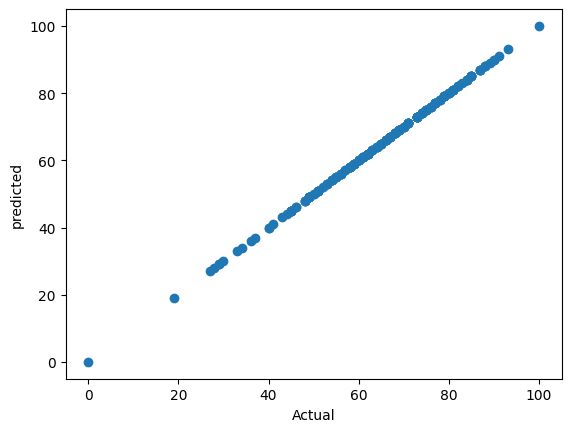

In [43]:
plt.scatter(Y_test , Y_pred)
plt.xlabel('Actual')
plt.ylabel('predicted')